In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py, math
import numpy as np
import healpy as hp
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy import stats
from tqdm import tqdm

from msfm.utils import files, catalog, observation, clustering

2026-02-17 01:02:41.637213: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-17 01:02:41.637242: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-17 01:02:41.638430: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-17 01:02:41.645641: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 01:02:43.470314: W tensorflow/compiler/tf2

In [2]:
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml"
conf = files.load_config(conf)

n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]
n_gal = np.array(conf["survey"]["metacal"]["n_gal"]) * hp.nside2pixarea(n_side, degrees=True)
apply_norm = False

mask = files.get_mask(conf, nest_out=False)
# hp.mollview(mask, title="mask")

# DES

In [3]:
des_gamma_map, des_count_map = catalog.build_metacal_map_from_cat(conf)

des_gamma_map *= mask[:,np.newaxis, np.newaxis]
des_count_map *= mask[:,np.newaxis]

26-02-17 01:02:54   catalog.py WAR   Compare with Table 1 in https://arxiv.org/pdf/2105.13543 
26-02-17 01:02:54   catalog.py INF   Metacalibration bin 1 
26-02-17 01:02:54   catalog.py INF   N_gal = 24940465, n_eff = 1.476 [arcmin^-2] 
26-02-17 01:02:55   catalog.py INF   mean(e1) = 3.22e-04, mean(e2) = 1.60e-04 
26-02-17 01:02:55   catalog.py INF   sigma_e (H12) = 0.245, sigma_e (C13) = 0.187 
26-02-17 01:02:56   catalog.py INF   mean(R_gamma) = 0.7636 
26-02-17 01:02:57   catalog.py INF   z_mean (DNF) = 0.3305 
26-02-17 01:03:03   catalog.py INF   Metacalibration bin 2 
26-02-17 01:03:03   catalog.py INF   N_gal = 25280405, n_eff = 1.479 [arcmin^-2] 
26-02-17 01:03:03   catalog.py INF   mean(e1) = 3.36e-04, mean(e2) = 3.74e-05 
26-02-17 01:03:03   catalog.py INF   sigma_e (H12) = 0.265, sigma_e (C13) = 0.191 
26-02-17 01:03:04   catalog.py INF   mean(R_gamma) = 0.7182 
26-02-17 01:03:05   catalog.py INF   z_mean (DNF) = 0.5133 
26-02-17 01:03:11   catalog.py INF   Metacalibration bi

In [4]:
# hp.mollview(des_gamma_map[:,iz,0], title=r"DES Y3 $\gamma_1$")
# hp.mollview(des_gamma_map[:,iz,1], title=r"DES Y3 $\gamma_2$")
# hp.mollview(des_count_map[:,iz], title="DES Y3 counts")

# shape noise (forward modeled)

### True

In [5]:
ref_gamma_map = observation.make_shape_noise_map(des_count_map, conf)

26-02-17 01:03:25     files.py INF   Loaded the noise file 


2026-02-17 01:03:26.092963: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 887 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0


In [6]:
# hp.mollview(sn_gamma_map[:,iz,0], title=r"shape noise $\gamma_1$")
# hp.mollview(sn_gamma_map[:,iz,1], title=r"shape noise $\gamma_2$")

### CosmoGrid forward model

In [7]:
cosmo_params = ["Om", "s8", "w0"]

meta_file = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/data/CosmoGridV1_metainfo.h5"
with h5py.File(meta_file, "r") as f:
    grid_params = f["parameters/grid"][:]
i_sobols = grid_params["sobol_index"]
grid_cosmo = np.stack([grid_params[param] for param in cosmo_params], axis=-1)

# from https://arxiv.org/pdf/2105.13549
des_cosmo = np.array([0.339, 0.73, -1]) # h = 0.7, ns = 0.96, Omega_b = 0.046 

param_min = grid_cosmo.min(axis=0)
param_max = grid_cosmo.max(axis=0)
grid_cosmo_normalized = (grid_cosmo - param_min) / (param_max - param_min)
des_cosmo_normalized = (des_cosmo - param_min) / (param_max - param_min)

distances = np.linalg.norm(grid_cosmo - des_cosmo, axis=1)

n = 5
closest_indices = np.argsort(distances)[:n]
closest_sobols = i_sobols[closest_indices]
closest_points = grid_cosmo[closest_indices]

print("closest", n, "points:\n", closest_points)
print("distances", distances[closest_indices])
print("indices:", closest_indices)
print("i_sobols:", closest_sobols)

i_sobol = closest_sobols[0]

closest 5 points:
 [[ 0.34465179  0.71697464 -1.0119675 ]
 [ 0.36083984  0.73618164 -0.99434644]
 [ 0.35690308  0.71929016 -1.02642174]
 [ 0.31104584  0.7361702  -1.01975104]
 [ 0.32272034  0.69935455 -1.02012623]]
distances [0.01856943 0.02339133 0.03366495 0.03477945 0.04011528]
indices: [2276 1010 1481 2420 1894]
i_sobols: [167470   2630  39878 192702 106078]


In [8]:
z_bins = conf["survey"]["metacal"]["z_bins"]
n_z = len(z_bins)

grid_dir = "/global/cfs/cdirs/des/cosmogrid/processed/v11desy3/CosmoGrid/bary/grid"
grid_file = os.path.join(grid_dir, f"cosmo_{i_sobol:06d}", "perm_0000/projected_probes_maps_v11dmb.h5")

delta_m = []
with h5py.File(grid_file, "r") as f:
    for z_bin in z_bins:
        temp = f[f"map/dg/{z_bin}"][:]
        temp = hp.ud_grade(temp, nside_out=n_side)
        delta_m.append(temp)
delta_m = np.stack(delta_m, axis=-1)

delta_m_fp = delta_m[mask]
delta_m_fp = (delta_m_fp - np.mean(delta_m_fp))/np.mean(delta_m_fp)

In [9]:
bg = files.read_metacal_bias(f"cosmo_{i_sobol:06d}", conf)
n_g_fp = clustering.galaxy_density_to_count(n_gal, delta_m_fp, bg)

n_g_map = np.zeros((n_pix, n_z), dtype=int)
n_g_map[mask] = n_g_fp

fm_gamma_map = observation.make_shape_noise_map(n_g_map, conf)

26-02-17 01:03:40     files.py INF   Loaded the noise file 


# diagnostics

In [10]:
des_gamma_fp = des_gamma_map[mask]
ref_gamma_fp = ref_gamma_map[mask]
fm_gamma_fp = fm_gamma_map[mask]

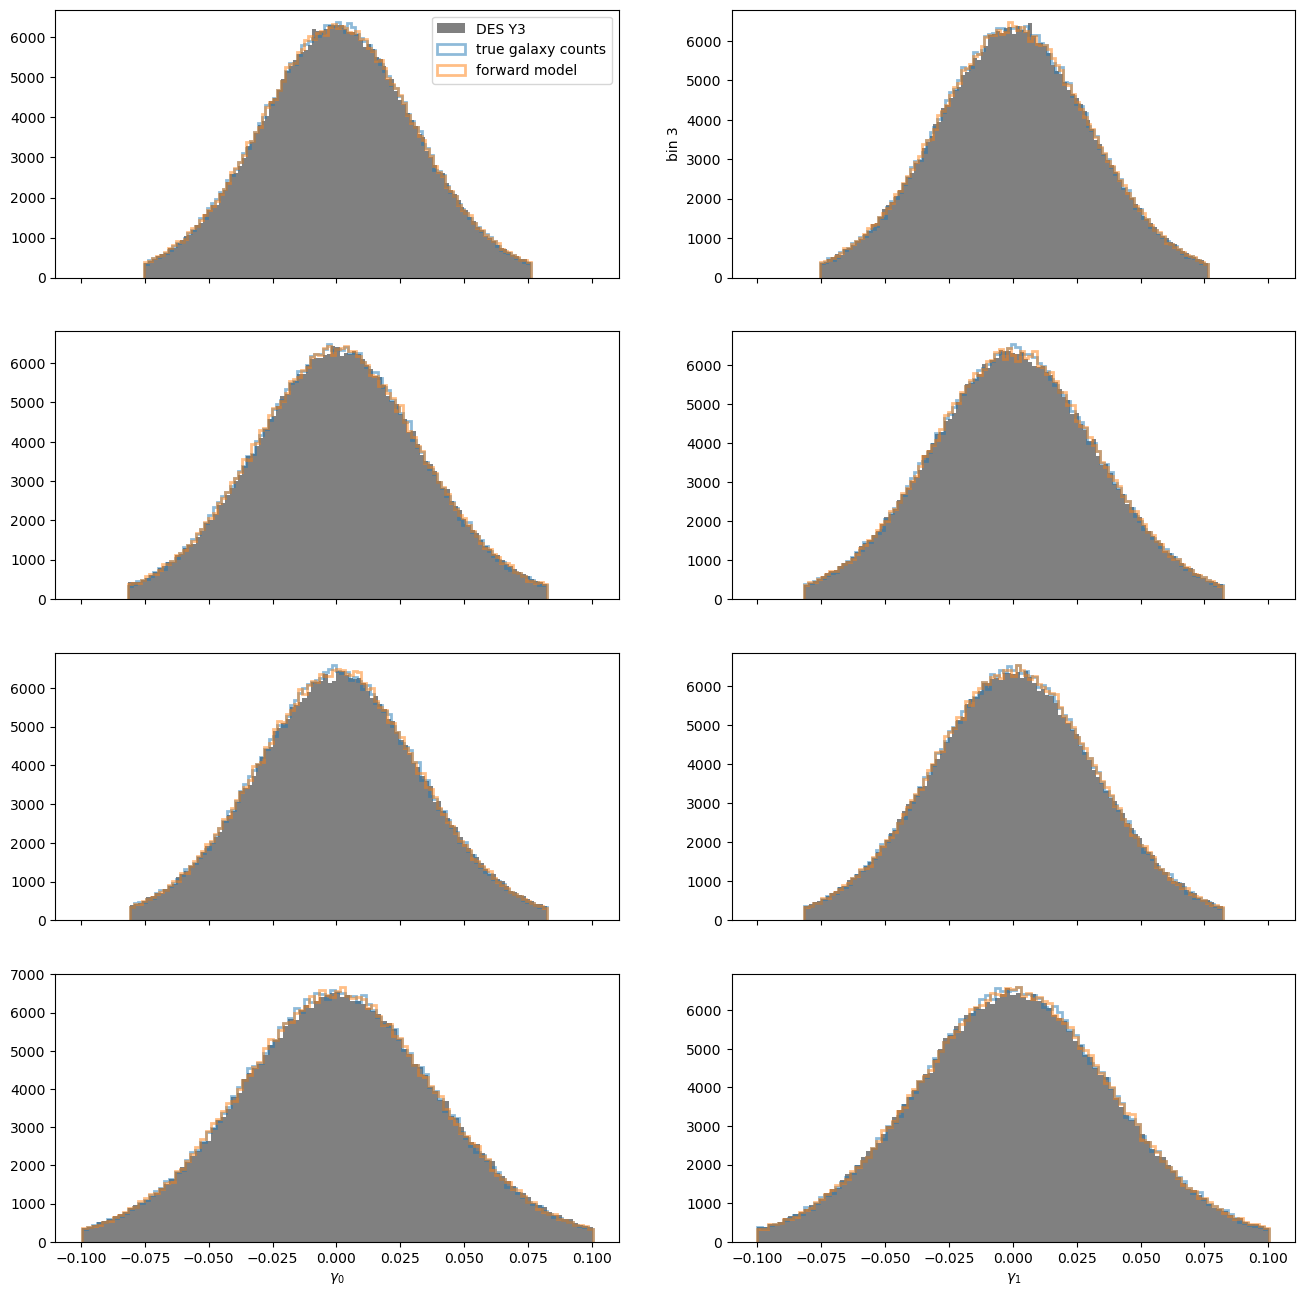

In [11]:
n_z = 4
q_low = 0.01
q_high = 0.99

nrows = n_z
ncols = 2
fig, ax = plt.subplots(figsize=(8*ncols, 4*nrows), nrows=nrows, ncols=ncols, sharex=True)

for i in range(nrows):
    ax[0,1].set(ylabel=f"bin {i}")
    
    for j in range(ncols):
        des = des_gamma_fp[:,i,j]
        ref = ref_gamma_fp[:,i,j]
        fm = fm_gamma_fp[:,i,j]
        
        # _, bins = np.histogram(des, bins=500)     
        bins = np.linspace(np.quantile(des, 0.01), np.quantile(des, 0.99), 100)
        
        ax[i,j].hist(des, bins, label="DES Y3", color="grey")
        ax[i,j].hist(ref, bins, label="true galaxy counts", color="tab:blue", histtype="step", linewidth=2, alpha=0.5)
        ax[i,j].hist(fm, bins, label="forward model", color="tab:orange", histtype="step", linewidth=2, alpha=0.5)

ax[0,0].legend()

for j in range(ncols):
    ax[-1,j].set(xlabel=r"$\gamma_" + str(j) + r"$")

# varying source clustering bias

In [13]:
bgs = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

sn_fpes = []
for bg in bgs:
    n_g_fp = clustering.galaxy_density_to_count(
        n_gal,
        delta_m_fp,
        bg,
    )
    
    n_g_map = np.zeros((n_pix, n_z), dtype=int)
    n_g_map[mask] = n_g_fp

    sn_map = observation.make_shape_noise_map(n_g_map, conf)
    sn_fp = sn_map[mask]
    sn_fpes.append(sn_fp)
sn_fpes = np.stack(sn_fpes, axis=0)

26-02-17 01:04:13     files.py INF   Loaded the noise file 
26-02-17 01:04:20     files.py INF   Loaded the noise file 
26-02-17 01:04:26     files.py INF   Loaded the noise file 
26-02-17 01:04:33     files.py INF   Loaded the noise file 
26-02-17 01:04:40     files.py INF   Loaded the noise file 
26-02-17 01:04:47     files.py INF   Loaded the noise file 


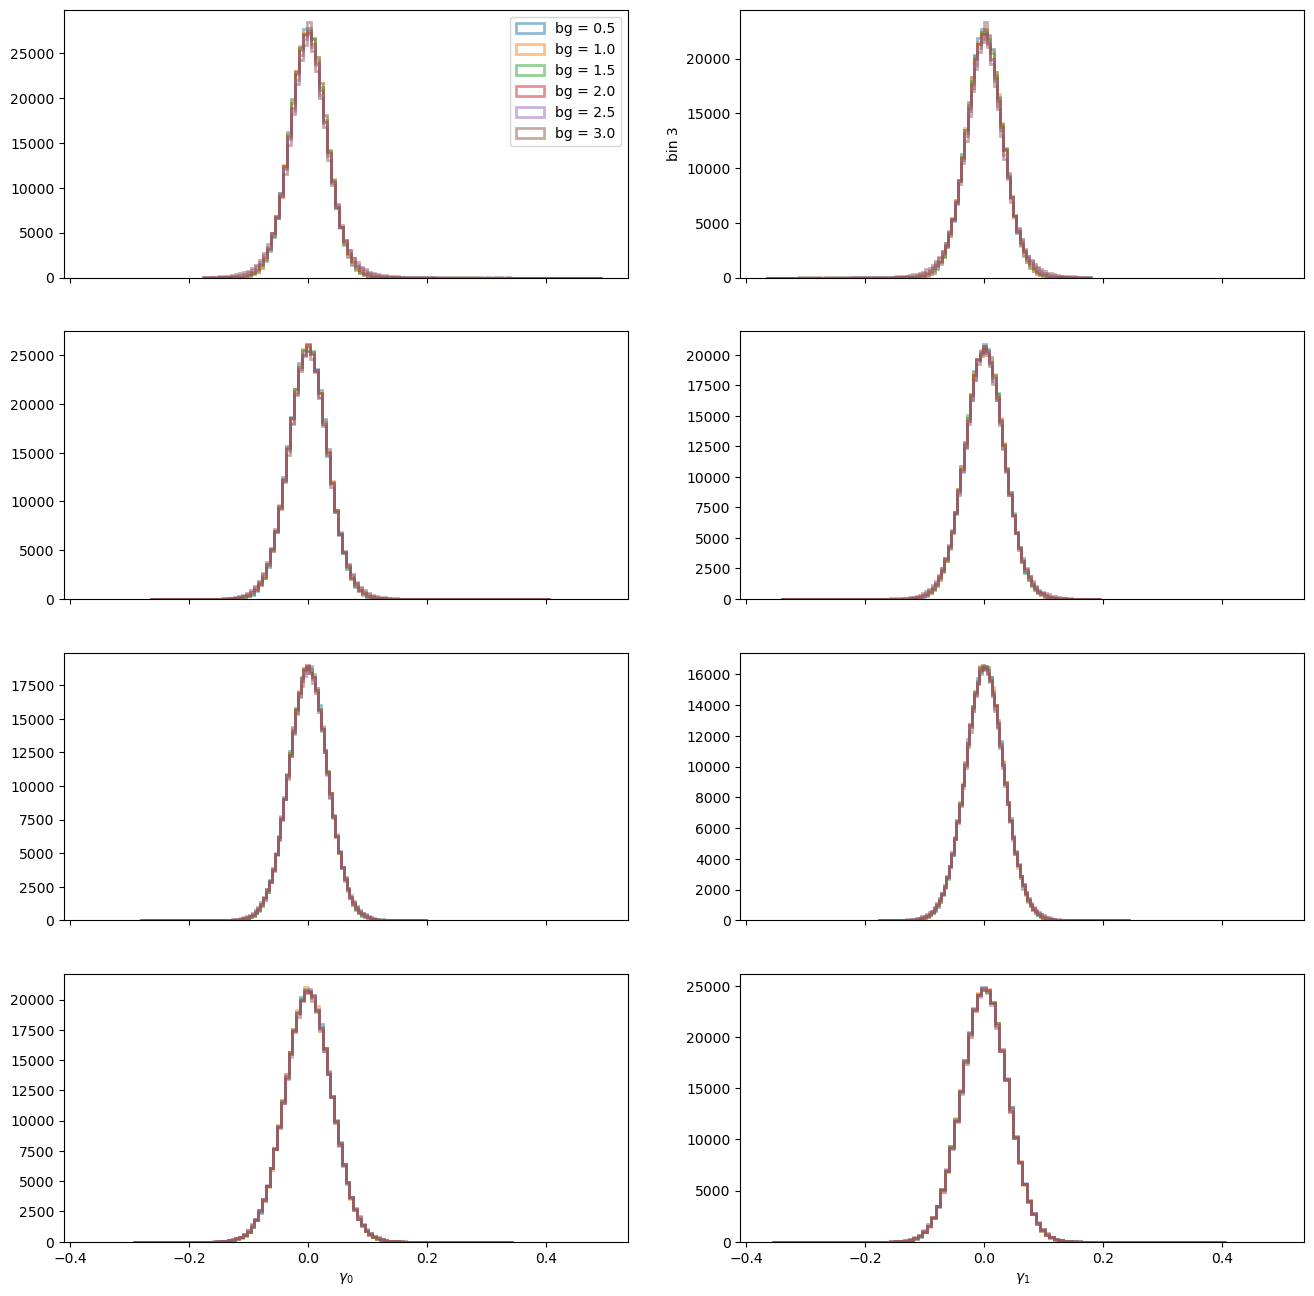

In [14]:
n_z = 4
n_bgs = len(bgs)

nrows = n_z
ncols = 2
fig, ax = plt.subplots(figsize=(8*ncols, 4*nrows), nrows=nrows, ncols=ncols, sharex=True)

for i in range(nrows):
    ax[0,1].set(ylabel=f"bin {i}")
    
    for j in range(ncols):
        des = des_gamma_fp[:,i,j]
        _, bins = np.histogram(des, bins=100)

        # ax[i,j].hist(des, bins, label="DES Y3", color="tab:blue", alpha=0.5)
        
        for k, bg in enumerate(bgs):
            sn = sn_fpes[k,:,i,j]
            ax[i,j].hist(sn, bins, label=f"bg = {bg}", alpha=0.5, histtype="step", linewidth=2)
        
ax[0,0].legend()

for j in range(ncols):
    ax[-1,j].set(xlabel=r"$\gamma_" + str(j) + r"$")